In [56]:
#环境配置
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

In [57]:
#定义输入文件简化数据库
data_dir = Path(r"d:\project")
file_path = data_dir / "sample_dataset.csv"

cols = [
    "user_id",
    "tool",
    "use_case",
    "final_quality_label",
    "hallucination_flag",
    "failure_type",
    "session_length"
]

df = pd.read_csv(file_path, usecols=cols)

print(df.shape)
print(df.head())


(5000, 7)
   user_id           tool          use_case final_quality_label  \
0    43140        ChatGPT      Blog Writing                high   
1     9263  Perplexity AI     Medical Notes                high   
2    33655   Grammarly AI  Image Generation                high   
3    11705         Claude    Marketing Copy              medium   
4     4384         Gemini    Marketing Copy              medium   

   hallucination_flag failure_type  session_length  
0                   0         none              13  
1                   0         none               6  
2                   0         none              56  
3                   0         none              44  
4                   0         none              36  


In [ ]:
#数据加载与预处理函数
def load_and_preprocess(filepath):
    """从原始表中读取指定列，并完成基础预处理"""
    filepath = Path(filepath)

    # 1. 检查文件是否存在
    if not filepath.exists():
        raise FileNotFoundError(
            f"未找到输入文件: {filepath}\n"
            "请检查 sample_dataset.csv 是否在 d:\\project 目录下。"
        )

    # 2. 只读取你要保留的这几列
    if filepath.suffix.lower() == ".csv":
        df = pd.read_csv(filepath, usecols=cols)
    elif filepath.suffix.lower() == ".xlsx":
        df = pd.read_excel(filepath, usecols=cols)
    else:
        raise ValueError(f"暂不支持的文件格式: {filepath.suffix}")

    # 3. 基础数据质量检查
    print("=" * 60)
    print("第一阶段：数据加载与质量检查")
    print("=" * 60)
    print(f"输入文件: {filepath.name}")
    print(f"数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"缺失值总数: {int(df.isnull().sum().sum())}")
    print(f"整行重复数: {int(df.duplicated().sum())}")

    # 4. 文本列标准化
    text_cols = [
        "tool",
        "use_case",
        "final_quality_label",
        "failure_type"
    ]

    for col in text_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()

    # 5. hallucination_flag 转成数值型
    df["hallucination_flag"] = (
        pd.to_numeric(df["hallucination_flag"], errors="coerce")
        .fillna(0)
        .astype("int8")
    )

    # 6. failure_type 兜底处理
    df["failure_type"] = (
        df["failure_type"]
        .replace({"nan": "none", "": "none"})
        .fillna("none")
    )

    # 7. 预处理后检查
    print("\n预处理后检查:")
    print(f"tool 唯一值数量: {df['tool'].nunique()}")
    print(f"use_case 唯一值数量: {df['use_case'].nunique()}")
    print(f"final_quality_label 分布: {df['final_quality_label'].value_counts().to_dict()}")
    print(f"hallucination_flag 分布: {df['hallucination_flag'].value_counts().to_dict()}")
    print(f"failure_type 分布: {df['failure_type'].value_counts().to_dict()}")
    print(f"session_length 描述统计:\n{df['session_length'].describe()}")

    return df


# 执行第三部分
df = load_and_preprocess(file_path)

print("\n前 5 行预览:")
print(df.head())

# 如果你还想保存成简化表
output_path = Path(r"d:\project\sample_dataset_simplified.csv")
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("\n简化表已保存:")
print(output_path)


第一阶段：数据加载与质量检查
输入文件: sample_dataset.csv
数据规模: 5000 行 x 7 列
缺失值总数: 0
整行重复数: 0

预处理后检查:
tool 唯一值数量: 16
use_case 唯一值数量: 18
final_quality_label 分布: {'high': 2632, 'medium': 2368}
hallucination_flag 分布: {0: 3529, 1: 1471}
failure_type 分布: {'none': 3529, 'incomplete': 499, 'irrelevant': 492, 'hallucination': 480}
session_length 描述统计:
count    5000.00000
mean       32.62220
std        16.42886
min         5.00000
25%        18.00000
50%        33.00000
75%        47.00000
max        60.00000
Name: session_length, dtype: float64

前 5 行预览:
   user_id           tool          use_case final_quality_label  \
0    43140        chatgpt      blog writing                high   
1     9263  perplexity ai     medical notes                high   
2    33655   grammarly ai  image generation                high   
3    11705         claude    marketing copy              medium   
4     4384         gemini    marketing copy              medium   

   hallucination_flag failure_type  session_length  
0      

hallucination_flag == 1 的 session_length：


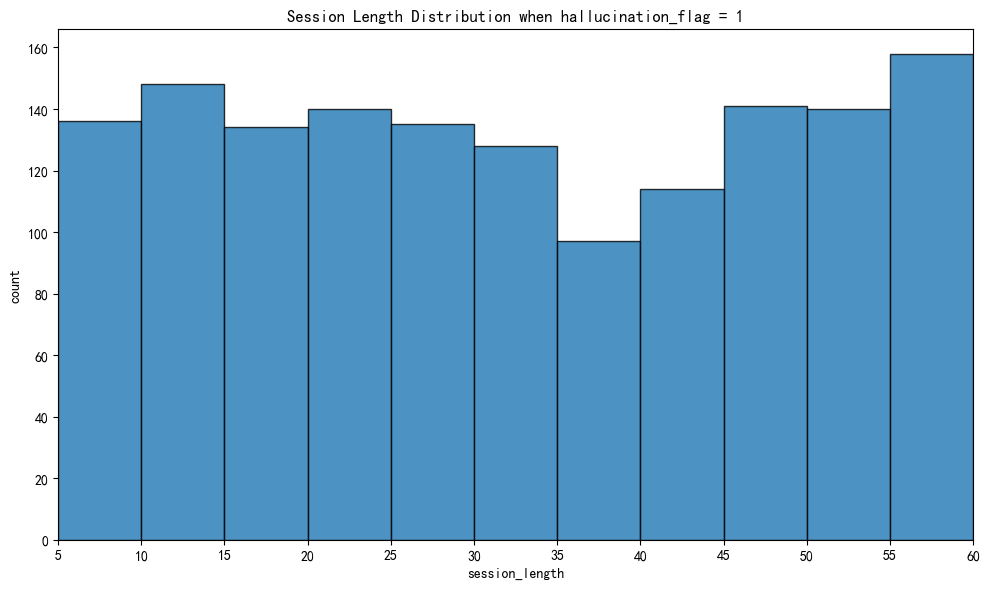

In [ ]:
# 筛选 hallucination_flag = 1，并绘制 session_length 直方图
filtered = df[df["hallucination_flag"] == 1].copy()
session_lengths = filtered["session_length"].dropna()

print("hallucination_flag == 1 的 session_length：")

session_lengths.to_frame(name="session_length").to_csv(
    r"d:\project\hallucination_session_length.csv",
    index=False,
    encoding="utf-8-sig"
)

plot_data = session_lengths[(session_lengths >= 5) & (session_lengths <= 60)]
bins = list(range(5, 65, 5))

plt.figure(figsize=(10, 6))
plt.hist(plot_data, bins=bins, edgecolor="black", alpha=0.8)
plt.title("Session Length Distribution when hallucination_flag = 1")
plt.xlabel("session_length")
plt.ylabel("count")
plt.xticks(bins)
plt.xlim(5, 60)
plt.tight_layout()
plt.savefig(r"d:\project\hallucination_session_length_hist.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
#初步观察参数faliure_type
def count_error_type(df):
    """对 failure_type 进行计数，并返回结果表"""
    error_counts = (
        df["failure_type"]
        .value_counts()
        .reset_index()
    )
    error_counts.columns = ["failure_type", "count"]

    print("=" * 60)
    print("failure_type 计数结果")
    print("=" * 60)
    print(error_counts)

    return error_counts
error_counts = count_error_type(df)

failure_type 计数结果
    failure_type  count
0           none   3529
1     incomplete    499
2     irrelevant    492
3  hallucination    480


筛选 incomplete error type 结果
原始数据规模: 5000 行 x 7 列
incomplete 数据规模: 499 行 x 7 列

incomplete 分布：
failure_type
incomplete    499
Name: count, dtype: int64
    user_id            tool               use_case final_quality_label  \
29    20353       cursor ai          medical notes              medium   
40    20135         autogpt         video creation              medium   
54    14386  github copilot  presentation creation                high   
62    45271          dall-e  presentation creation                high   
69    26395       runway ai         marketing copy                high   

    hallucination_flag failure_type  session_length  
29                   1   incomplete              18  
40                   1   incomplete              33  
54                   1   incomplete              20  
62                   1   incomplete              49  
69                   1   incomplete              23  
failure_type = incomplete 在 session_length 5-60 分段中的计数
incomplete 记录数: 499

5-60

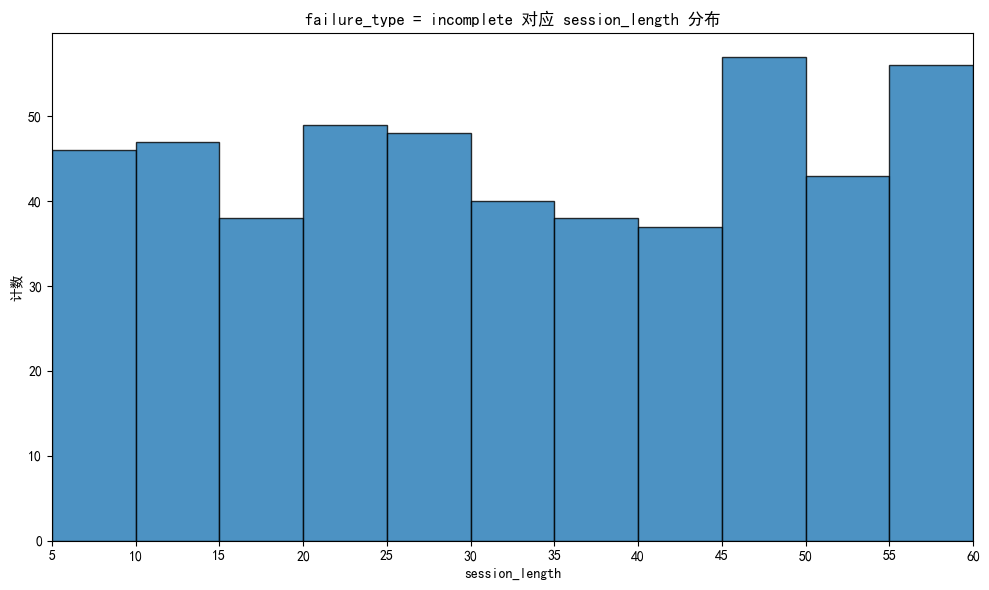

In [ ]:
#failure_type = icomplete 对应 session_length 分布，构造直方图
def filter_error_type1(df):
    """筛选出 failure_type 为 incomplete 的记录表"""
    print("=" * 60)
    print("筛选 incomplete error type 结果")
    print("=" * 60)

    error_df = df[df["failure_type"].astype(str).str.strip().str.lower() == "incomplete"].copy()

    print(f"原始数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"incomplete 数据规模: {error_df.shape[0]} 行 x {error_df.shape[1]} 列")
    print("\nincomplete 分布：")
    print(error_df["failure_type"].value_counts())

    return error_df


error_type1 = filter_error_type1(df)
print(error_type1.head())
def plot_incomplete_by_session_length(df):
    """按 session_length 分段统计 failure_type = incomplete，并绘制直方图"""
    print("=" * 60)
    print("failure_type = incomplete 在 session_length 5-60 分段中的计数")
    print("=" * 60)

    # 先筛选出 failure_type = incomplete
    plot_df = df[["failure_type", "session_length"]].copy()
    plot_df["failure_type"] = plot_df["failure_type"].astype(str).str.strip().str.lower()
    plot_df["session_length"] = pd.to_numeric(plot_df["session_length"], errors="coerce")

    plot_df = plot_df[plot_df["failure_type"] == "incomplete"].copy()
    plot_df = plot_df.dropna(subset=["session_length"])

    # 只保留 5 到 60 的区间
    plot_df = plot_df[(plot_df["session_length"] >= 5) & (plot_df["session_length"] <= 60)]

    # 定义分段
    bins = list(range(5, 65, 5))

    print(f"incomplete 记录数: {len(plot_df)}")

    # 计算 session_length 分段计数
    bin_counts = pd.cut(
        plot_df["session_length"],
        bins=bins,
        include_lowest=True,
        right=True
    ).value_counts(sort=False)

    print("\n5-60 分段计数：")
    print(bin_counts.to_string())

    # 绘图
    plt.figure(figsize=(10, 6))
    plt.hist(plot_df["session_length"], bins=bins, edgecolor="black", alpha=0.8)
    plt.title("failure_type = incomplete 对应 session_length 分布")
    plt.xlabel("session_length")
    plt.ylabel("计数")
    plt.xticks(bins)
    plt.xlim(5, 60)
    plt.tight_layout()
    plt.show()

    return plot_df, bin_counts
incomplete_df, bin_counts = plot_incomplete_by_session_length(df)

筛选 incomplete error type 结果
原始数据规模: 5000 行 x 7 列
irrelevant 数据规模: 492 行 x 7 列

irrelevant 分布：
failure_type
irrelevant    492
Name: count, dtype: int64
    user_id                tool         use_case final_quality_label  \
13     8869           synthesia     blog writing                high   
15    40180  replit ghostwriter  code generation              medium   
16    48551              dall-e     blog writing              medium   
25    23465             pictory        ui design              medium   
43    23266          midjourney     blog writing                high   

    hallucination_flag failure_type  session_length  
13                   1   irrelevant              13  
15                   1   irrelevant               7  
16                   1   irrelevant              36  
25                   1   irrelevant              38  
43                   1   irrelevant              53  
failure_type = irrelevant 在 session_length 5-60 分段中的计数
irrelevant 记录数: 492

5-60 分段计数：
sessi

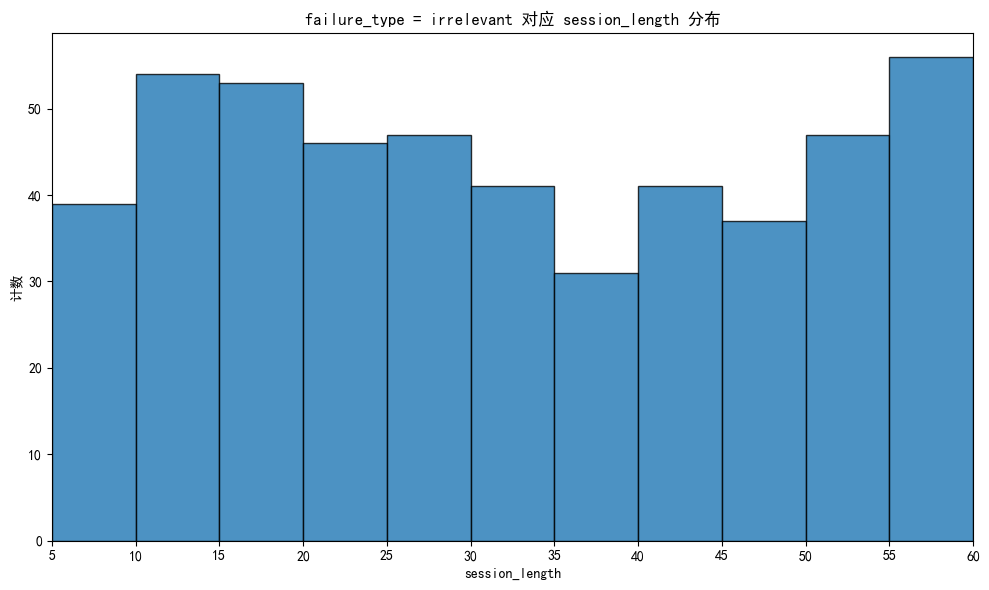

In [ ]:
#failure_type = irrelevant 对应 session_length 分布，构造直方图
def filter_error_type2(df):
    """筛选出 failure_type 为 irrelevant 的记录表"""
    print("=" * 60)
    print("筛选 incomplete error type 结果")
    print("=" * 60)

    error_df = df[df["failure_type"].astype(str).str.strip().str.lower() == "irrelevant"].copy()

    print(f"原始数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"irrelevant 数据规模: {error_df.shape[0]} 行 x {error_df.shape[1]} 列")
    print("\nirrelevant 分布：")
    print(error_df["failure_type"].value_counts())

    return error_df


error_type2 = filter_error_type2(df)
print(error_type2.head())
def plot_irrelevant_by_session_length(df):
    """按 session_length 分段统计 failure_type = irrelevant，并绘制直方图"""
    print("=" * 60)
    print("failure_type = irrelevant 在 session_length 5-60 分段中的计数")
    print("=" * 60)

    # 先筛选出 failure_type = irrelevant
    plot_df = df[["failure_type", "session_length"]].copy()
    plot_df["failure_type"] = plot_df["failure_type"].astype(str).str.strip().str.lower()
    plot_df["session_length"] = pd.to_numeric(plot_df["session_length"], errors="coerce")

    plot_df = plot_df[plot_df["failure_type"] == "irrelevant"].copy()
    plot_df = plot_df.dropna(subset=["session_length"])

    # 只保留 5 到 60 的区间
    plot_df = plot_df[(plot_df["session_length"] >= 5) & (plot_df["session_length"] <= 60)]

    # 定义分段
    bins = list(range(5, 65, 5))

    print(f"irrelevant 记录数: {len(plot_df)}")

    # 计算 session_length 分段计数
    bin_counts = pd.cut(
        plot_df["session_length"],
        bins=bins,
        include_lowest=True,
        right=True
    ).value_counts(sort=False)

    print("\n5-60 分段计数：")
    print(bin_counts.to_string())

    # 绘图
    plt.figure(figsize=(10, 6))
    plt.hist(plot_df["session_length"], bins=bins, edgecolor="black", alpha=0.8)
    plt.title("failure_type = irrelevant 对应 session_length 分布")
    plt.xlabel("session_length")
    plt.ylabel("计数")
    plt.xticks(bins)
    plt.xlim(5, 60)
    plt.tight_layout()
    plt.show()

    return plot_df, bin_counts
irrelevant_df, irrelevant_bin_counts = plot_irrelevant_by_session_length(df)

筛选 hallucination error type 结果
原始数据规模: 5000 行 x 7 列
hallucination数据规模: 480 行 x 7 列

hallucination 分布：
failure_type
hallucination    480
Name: count, dtype: int64
    user_id            tool          use_case final_quality_label  \
7     16150        canva ai   resume building              medium   
9     19668         pictory    email drafting                high   
11    44302          gemini    legal drafting                high   
14    19374  github copilot  research summary              medium   
23    30947          claude         ui design              medium   

    hallucination_flag   failure_type  session_length  
7                    1  hallucination              22  
9                    1  hallucination              11  
11                   1  hallucination              35  
14                   1  hallucination              51  
23                   1  hallucination              55  
failure_type = hallucination 在 session_length 5-60 分段中的计数
hallucination 记录数: 480

5-60 

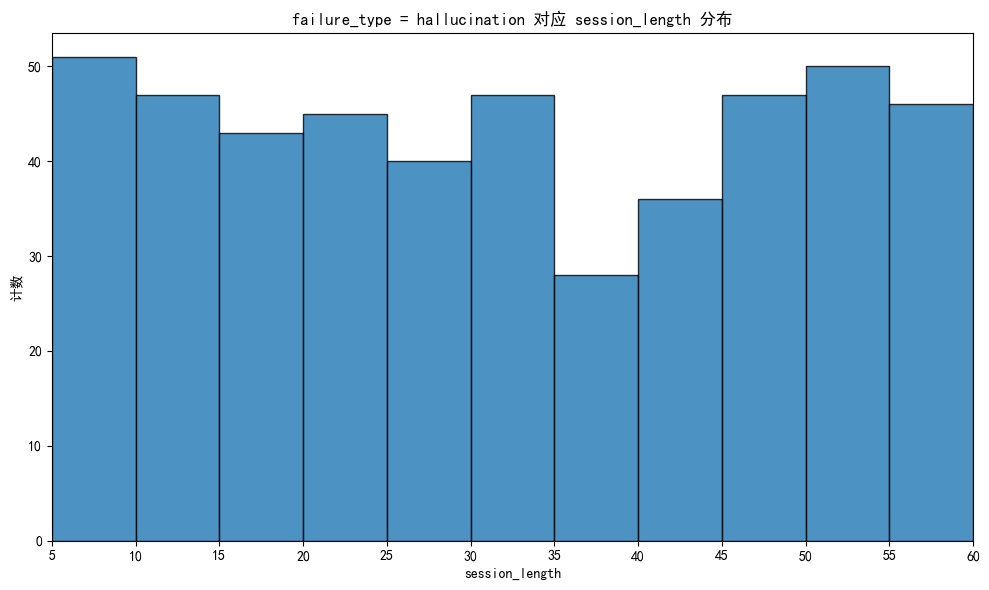

In [ ]:
#failure_type = hallucination 对应 session_length 分布，构造直方图
def filter_error_type3(df):
    """筛选出 failure_type 为 hallucination 的记录表"""
    print("=" * 60)
    print("筛选 hallucination error type 结果")
    print("=" * 60)

    error_df = df[df["failure_type"].astype(str).str.strip().str.lower() == "hallucination"].copy()

    print(f"原始数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"hallucination数据规模: {error_df.shape[0]} 行 x {error_df.shape[1]} 列")
    print("\nhallucination 分布：")
    print(error_df["failure_type"].value_counts())

    return error_df


error_type3 = filter_error_type3(df)
print(error_type3.head())
def plot_hallucination_error_by_session_length(df):
    """按 session_length 分段统计 failure_type = hallucination，并绘制直方图"""
    print("=" * 60)
    print("failure_type = hallucination 在 session_length 5-60 分段中的计数")
    print("=" * 60)

    # 先筛选出 failure_type = hallucination
    plot_df = df[["failure_type", "session_length"]].copy()
    plot_df["failure_type"] = plot_df["failure_type"].astype(str).str.strip().str.lower()
    plot_df["session_length"] = pd.to_numeric(plot_df["session_length"], errors="coerce")

    plot_df = plot_df[plot_df["failure_type"] == "hallucination"].copy()
    plot_df = plot_df.dropna(subset=["session_length"])

    # 只保留 5 到 60 的区间
    plot_df = plot_df[(plot_df["session_length"] >= 5) & (plot_df["session_length"] <= 60)]

    # 定义分段
    bins = list(range(5, 65, 5))

    print(f"hallucination 记录数: {len(plot_df)}")

    # 计算 session_length 分段计数
    bin_counts = pd.cut(
        plot_df["session_length"],
        bins=bins,
        include_lowest=True,
        right=True
    ).value_counts(sort=False)

    print("\n5-60 分段计数：")
    print(bin_counts.to_string())

    # 绘图
    plt.figure(figsize=(10, 6))
    plt.hist(plot_df["session_length"], bins=bins, edgecolor="black", alpha=0.8)
    plt.title("failure_type = hallucination 对应 session_length 分布")
    plt.xlabel("session_length")
    plt.ylabel("计数")
    plt.xticks(bins)
    plt.xlim(5, 60)
    plt.tight_layout()
    plt.show()

    return plot_df, bin_counts
hallucination_df, hallucination_bin_counts = plot_hallucination_error_by_session_length(df)

In [ ]:
#创建交叉表，分析参数error_type与hallcination_flag的关系
def create_cross_table(df):
    """创建 hallucination_flag 和 failure_type 的交叉表"""
    print("=" * 60)
    print("hallucination_flag 与 failure_type 的交叉表")
    print("=" * 60)

    temp_df = df.copy()
    temp_df["failure_type"] = (
        temp_df["failure_type"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({"": "none", "nan": "none"})
    )
    temp_df["hallucination_flag"] = (
        pd.to_numeric(temp_df["hallucination_flag"], errors="coerce")
        .fillna(0)
        .astype(int)
    )

    cross_tab = pd.crosstab(
        temp_df["failure_type"],
        temp_df["hallucination_flag"],
        margins=True
    )

    print(cross_tab)
    return cross_tab
cross_table = create_cross_table(df)

hallucination_flag 与 failure_type 的交叉表
hallucination_flag     0     1   All
failure_type                        
hallucination          0   480   480
incomplete             0   499   499
irrelevant             0   492   492
none                3529     0  3529
All                 3529  1471  5000


failure_type = hallucination 的 session_length 分段统计与线性拟合
hallucination 记录数: 480

5-60 分段计数：
中心点 7.5 -> 计数 51
中心点 12.5 -> 计数 47
中心点 17.5 -> 计数 43
中心点 22.5 -> 计数 45
中心点 27.5 -> 计数 40
中心点 32.5 -> 计数 47
中心点 37.5 -> 计数 28
中心点 42.5 -> 计数 36
中心点 47.5 -> 计数 47
中心点 52.5 -> 计数 50
中心点 57.5 -> 计数 46

线性回归结果：
回归方程: y = -0.0564x + 45.4682
R² = 0.0193


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_50924\2190967514.py:60: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


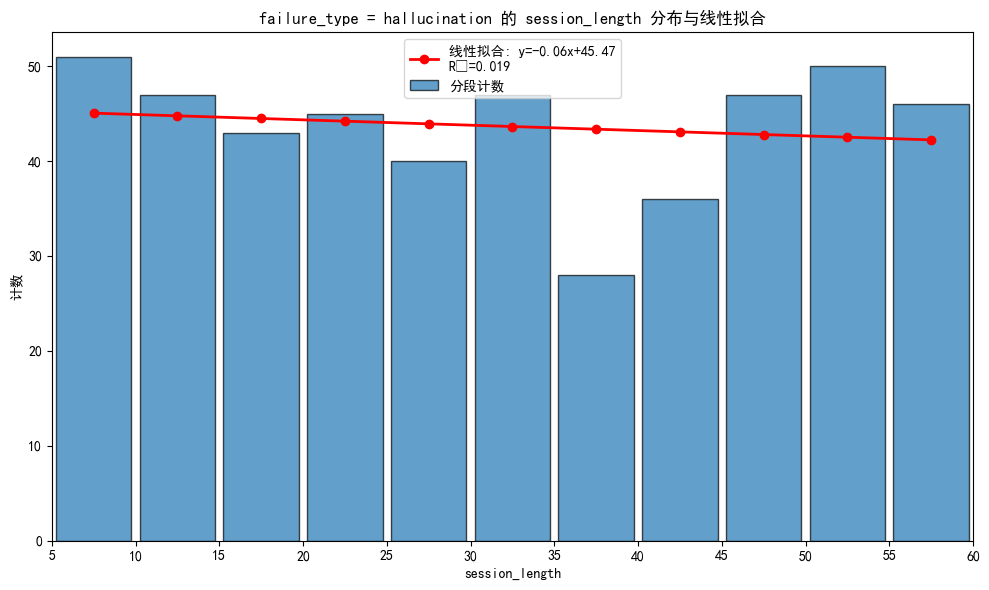

failure_type = incomplete 的 session_length 分段统计与线性拟合
incomplete 记录数: 499

5-60 分段计数：
中心点 7.5 -> 计数 46
中心点 12.5 -> 计数 47
中心点 17.5 -> 计数 38
中心点 22.5 -> 计数 49
中心点 27.5 -> 计数 48
中心点 32.5 -> 计数 40
中心点 37.5 -> 计数 38
中心点 42.5 -> 计数 37
中心点 47.5 -> 计数 57
中心点 52.5 -> 计数 43
中心点 57.5 -> 计数 56

线性回归结果：
回归方程: y = 0.1036x + 41.9955
R² = 0.0610


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_50924\2190967514.py:60: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


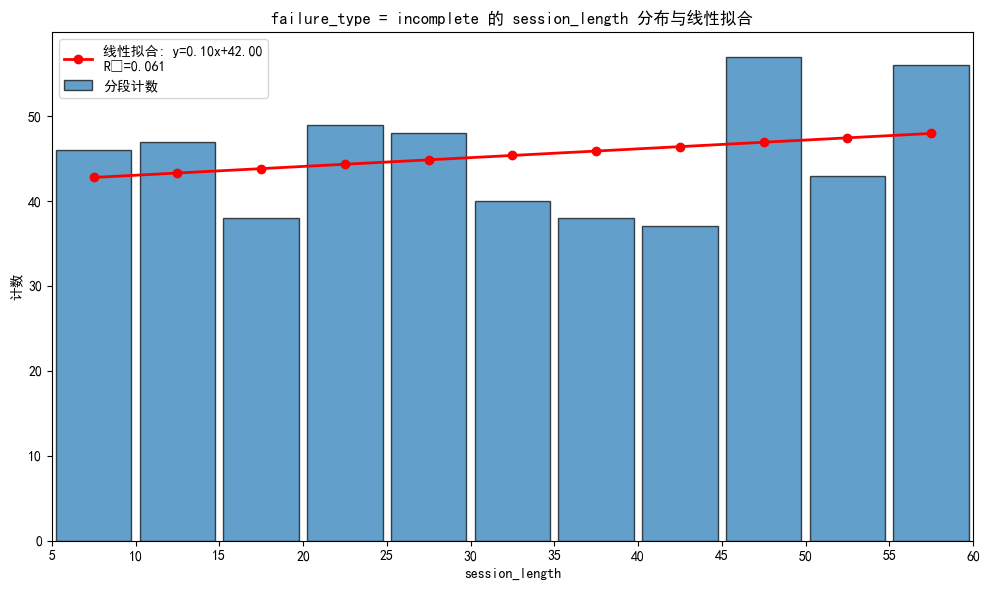

failure_type = irrelevant 的 session_length 分段统计与线性拟合
irrelevant 记录数: 492

5-60 分段计数：
中心点 7.5 -> 计数 39
中心点 12.5 -> 计数 54
中心点 17.5 -> 计数 53
中心点 22.5 -> 计数 46
中心点 27.5 -> 计数 47
中心点 32.5 -> 计数 41
中心点 37.5 -> 计数 31
中心点 42.5 -> 计数 41
中心点 47.5 -> 计数 37
中心点 52.5 -> 计数 47
中心点 57.5 -> 计数 56

线性回归结果：
回归方程: y = -0.0309x + 45.7318
R² = 0.0044


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_50924\2190967514.py:60: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\Lenovo\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


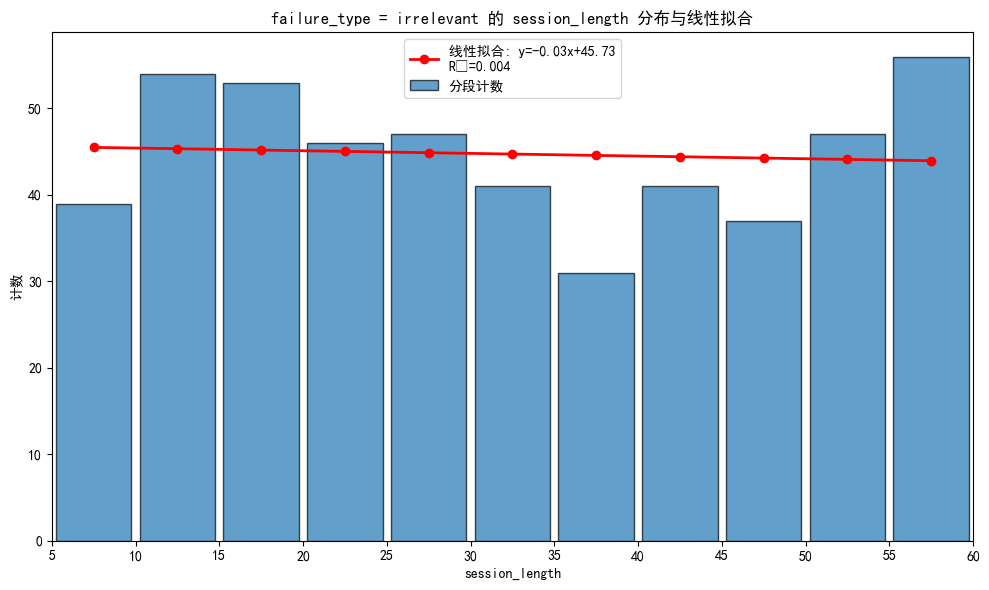

In [ ]:
#对各个error_type进行与时间的线性相关性，并进行回归性分析
def plot_error_with_linear_fit(df, error_type):
    """对指定 failure_type 的 session_length 分段计数做直方图，并进行线性拟合"""
    print("=" * 60)
    print(f"failure_type = {error_type} 的 session_length 分段统计与线性拟合")
    print("=" * 60)

    # 1. 取出需要的列
    plot_df = df[["failure_type", "session_length"]].copy()
    plot_df["failure_type"] = plot_df["failure_type"].astype(str).str.strip().str.lower()
    plot_df["session_length"] = pd.to_numeric(plot_df["session_length"], errors="coerce")

    # 2. 只保留指定 error_type
    plot_df = plot_df[plot_df["failure_type"] == error_type].copy()
    plot_df = plot_df.dropna(subset=["session_length"])

    # 3. 只保留 5 到 60 分钟区间
    plot_df = plot_df[(plot_df["session_length"] >= 5) & (plot_df["session_length"] <= 60)]

    if plot_df.empty:
        print(f"没有筛选到 failure_type = {error_type} 的有效数据。")
        return None, None, None

    # 4. 定义分段
    bins = list(range(5, 65, 5))

    # 5. 计算每个分段的计数
    counts, edges = np.histogram(plot_df["session_length"], bins=bins)
    bin_centers = (edges[:-1] + edges[1:]) / 2

    print(f"{error_type} 记录数: {len(plot_df)}")
    print("\n5-60 分段计数：")
    for center, count in zip(bin_centers, counts):
        print(f"中心点 {center:.1f} -> 计数 {count}")

    # 6. 线性拟合：y = ax + b
    slope, intercept = np.polyfit(bin_centers, counts, 1)
    y_pred = slope * bin_centers + intercept

    # 7. 计算 R²
    ss_res = np.sum((counts - y_pred) ** 2)
    ss_tot = np.sum((counts - np.mean(counts)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    print("\n线性回归结果：")
    print(f"回归方程: y = {slope:.4f}x + {intercept:.4f}")
    print(f"R² = {r2:.4f}")

    # 8. 绘图：柱状图 + 拟合线
    plt.figure(figsize=(10, 6))
    plt.bar(bin_centers, counts, width=4.5, edgecolor="black", alpha=0.7, label="分段计数")
    plt.plot(bin_centers, y_pred, color="red", marker="o", linewidth=2,
             label=f"线性拟合: y={slope:.2f}x+{intercept:.2f}\nR²={r2:.3f}")

    plt.title(f"failure_type = {error_type} 的 session_length 分布与线性拟合")
    plt.xlabel("session_length")
    plt.ylabel("计数")
    plt.xticks(bins)
    plt.xlim(5, 60)
    plt.legend()
    plt.tight_layout()
    plt.show()

    result_df = pd.DataFrame({
        "bin_center": bin_centers,
        "count": counts,
        "predicted_count": y_pred
    })

    return plot_df, result_df, {"slope": slope, "intercept": intercept, "r2": r2}
hall_df, hall_result, hall_reg = plot_error_with_linear_fit(df, "hallucination")
inc_df, inc_result, inc_reg = plot_error_with_linear_fit(df, "incomplete")
irr_df, irr_result, irr_reg = plot_error_with_linear_fit(df, "irrelevant")


In [ ]:
#计算各部分及整个系统可靠度
def generate_R_t_from_fit(name, slope, intercept):
    a = intercept
    b = -slope
    expr = f"R_{name}(t) = exp(-({a:.2f})*t + 0.5*({b:.2f})*t^2)"
    return expr

R_hallucination = generate_R_t_from_fit(
    "hallucination",
    hall_reg["slope"],
    hall_reg["intercept"]
)

R_incomplete = generate_R_t_from_fit(
    "incomplete",
    inc_reg["slope"],
    inc_reg["intercept"]
)

R_irrelevant = generate_R_t_from_fit(
    "irrelevant",
    irr_reg["slope"],
    irr_reg["intercept"]
)

print(R_hallucination)
print(R_incomplete)
print(R_irrelevant)
Rsys = f"Rsys(t) = ({R_hallucination})*({R_incomplete})*({R_irrelevant})"
print(Rsys)


R_hallucination(t) = exp(-(45.47)*t + 0.5*(0.06)*t^2)
R_incomplete(t) = exp(-(42.00)*t + 0.5*(-0.10)*t^2)
R_irrelevant(t) = exp(-(45.73)*t + 0.5*(0.03)*t^2)
Rsys(t) = (R_hallucination(t) = exp(-(45.47)*t + 0.5*(0.06)*t^2))*(R_incomplete(t) = exp(-(42.00)*t + 0.5*(-0.10)*t^2))*(R_irrelevant(t) = exp(-(45.73)*t + 0.5*(0.03)*t^2))
